In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from absl import app, flags, logging
from ml_collections import config_flags
import os
from tqdm.notebook import trange

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering

import matplotlib.patches as patches
from scipy.optimize import curve_fit

import plotly.io as pio
pio.renderers.default = "notebook_connected"

import json
from ml_collections import ConfigDict

import plotly.graph_objects as go

from icl.linear.train_linear import train
from icl.linear.lr_config import get_config
from icl.linear.lr_task import *
from icl.linear.linear_utils import *
from icl.linear import DiscreteMMSE, Ridge
from icl.utils import visualize_attention

logging.set_verbosity(logging.INFO)
torch.set_printoptions(precision=3, sci_mode=False)
np.set_printoptions(precision=3, suppress=True)

%load_ext autoreload
%autoreload 2

In [2]:
config = get_config()
# config = u.filter_config(config)
model, log = train(config)

train_e10245847ff97d206408fa67bf11c03e already completed
Loaded model from ../results/linear/train_e10245847ff97d206408fa67bf11c03e/checkpoint.pt


In [3]:
work_dir = os.path.join("..", "results", "linear")
exp_dir = os.path.join(work_dir, "train_e10245847ff97d206408fa67bf11c03e")
config_path = os.path.join(exp_dir, "config.json")
with open(config_path, "r") as f:
    config_dict = json.load(f)

config = ConfigDict(config_dict)
checkpoint_path = os.path.join(exp_dir, "checkpoint.pt")
checkpoint = torch.load(checkpoint_path, map_location=config.device)
data_type = torch.float
model = get_model(**config["model"], dtype=data_type)
model.load_state_dict(checkpoint["model"])
model = model.to(config.device)
train_task = get_task(**config["task"])
train_task.batch_size = 1
demo_data, demo_target = train_task.sample_from_task(train_task.task_pool[0], step=1)
attns = get_attn(model, demo_data, demo_target)
cap = 100
attns_capped = {layer_key: tensor[:, :cap, :cap] for layer_key, tensor in attns.items()}

widget = visualize_attention(attns_capped, mode='widget')
widget

In [4]:
# Example usage:
# 
# # Basic usage
task_vectors, ws_dmmse, ws_re, data = analyze_tasks(
    config=config,
    model=model,
    data_type=data_type,
    batch_size=1024,
    layer_index=1,
    pos=1,
    return_data=True
)

plot_task_vector_differences(task_vectors)

In [5]:
plot_pairwise_task_vector_variance(task_vectors)

In [6]:
plot_task_vector_variance_with_fit(task_vectors)

In [7]:
dropdown = create_interactive_plot(task_vectors, ws_dmmse, ws_re, window_size=10, cap=170)

interactive(children=(Dropdown(description='Plot Type:', layout=Layout(width='200px'), options=('Task Vectors'…

In [8]:
t0 = 1
l0 = 1
train_task.batch_size = 1024
print(f"Memory allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")
criterion = nn.MSELoss(reduction='none')
tvs_means = task_vectors.mean(dim=-2)
tvs_mean_weighted = tvs_means[:, -10:].mean(dim=1)

for k in range(config.task.n_tasks):
    torch.cuda.empty_cache()
    task_idx = k
    query_data, query_target = train_task.sample_from_task(train_task.task_pool[task_idx], step=50)
    preds_rand = predict_with_task_vector(
            model=model,
            query_data=query_data[:, :(3*t0+3)],
            query_target=query_target[:, :(3*t0+3)],
            task_vector=tvs_mean_weighted[task_idx],
            l=l0,              # same layer
            pad="mapsto",      # same position
            pos=3*t0+1
        )
    with torch.no_grad():
        preds = model(query_data, query_target)
    
    errors_rand = criterion(preds_rand[:, t0], query_target[:, t0].to(preds_rand.device))  # shape: (batch,)
    errors_base = criterion(preds[:, t0], query_target[:, t0].to(preds_rand.device))
    loss = errors_rand.mean()
    baseline_loss = errors_base.mean()
    
    std_rand = errors_rand.std(unbiased=True)
    std_base = errors_base.std(unbiased=True)
    print(f"{t0}-shot loss w. injected task vector: {loss.item():.3f} ({std_rand.item():.3f})")
    print(f"{t0}-shot loss w.o. injected task vector: {baseline_loss.item():.3f} ({std_base.item():.3f})")

Memory allocated: 0.02 GB
1-shot loss w. injected task vector: 0.261 (0.370)
1-shot loss w.o. injected task vector: 1.739 (5.294)
1-shot loss w. injected task vector: 0.262 (0.380)
1-shot loss w.o. injected task vector: 1.452 (3.603)
1-shot loss w. injected task vector: 0.266 (0.380)
1-shot loss w.o. injected task vector: 1.484 (4.471)


In [10]:
train_task.batch_size = 1024
print(f"Memory allocated: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

torch.cuda.empty_cache()
_data, _, _target = train_task.sample_batch(step=8)
with torch.no_grad():
    preds = model(_data, _target)
loss = ((preds - _target.to(preds.device))**2).mean(dim=0)

RE = Ridge
dMMSE = DiscreteMMSE

re_preds = RE(_data, _target)
re_loss = ((re_preds - _target.to(re_preds.device))**2).mean(dim=0)

dmmse_preds = dMMSE(_data, _target)
dmmse_loss = ((dmmse_preds - _target.to(dmmse_preds.device))**2).mean(dim=0)

Memory allocated: 0.02 GB


AttributeError: 'Ridge' object has no attribute 'device'

In [26]:
# Prepare data
t = torch.arange(1, loss.shape[0] + 1).cpu().numpy()
loss_np = loss.cpu().numpy()
re_loss_np = re_loss.cpu().numpy() if isinstance(re_loss, torch.Tensor) else re_loss
dmmse_loss_np = dmmse_loss.cpu().numpy() if isinstance(dmmse_loss, torch.Tensor) else dmmse_loss

# Create figure
fig = go.Figure()

# Add Model
fig.add_trace(go.Scatter(
    x=t,
    y=loss_np,
    mode="lines+markers",
    name="Model",
    line=dict(width=2),
    marker=dict(size=4),
    hovertemplate="Position: %{x}<br>MSE: %{y:.6f}<extra>Model</extra>"
))

# Add Ridge
fig.add_trace(go.Scatter(
    x=t,
    y=re_loss_np,
    mode="lines+markers",
    name="Ridge",
    line=dict(width=2, dash="dash"),
    marker=dict(size=4),
    hovertemplate="Position: %{x}<br>MSE: %{y:.6f}<extra>Ridge</extra>"
))

# Add dMMSE
fig.add_trace(go.Scatter(
    x=t,
    y=dmmse_loss_np,
    mode="lines+markers",
    name="dMMSE",
    line=dict(width=2, dash="dot"),
    marker=dict(size=4),
    hovertemplate="Position: %{x}<br>MSE: %{y:.6f}<extra>dMMSE</extra>"
))

# Layout
fig.update_layout(
    title="Mean Squared Error vs Position",
    xaxis_title="Position",
    yaxis_title="MSE",
    template="plotly_white",
    legend=dict(title="Legend", itemsizing="constant"),
    height=500,
    width=800
)

fig.update_xaxes(showgrid=True, gridwidth=0.5, gridcolor='LightGray')
fig.update_yaxes(showgrid=True, gridwidth=0.5, gridcolor='LightGray')

fig.show()

In [27]:
# Prepare data
t = torch.arange(1, loss.shape[0] + 1).cpu().numpy()
diff_dmmse_np = np.abs(preds.mean(dim=0).cpu().numpy() - dmmse_preds.mean(dim=0).cpu().numpy())
diff_re_np = np.abs(preds.mean(dim=0).cpu().numpy() - re_preds.mean(dim=0).cpu().numpy())

# Create figure
fig = go.Figure()

# Add dMMSE
fig.add_trace(go.Scatter(
    x=t,
    y=diff_dmmse_np,
    mode="lines+markers",
    name="dMMSE",
    line=dict(width=2),
    marker=dict(size=4),
    hovertemplate="Position: %{x}<br>MSE: %{y:.6f}<extra>Model</extra>"
))

# Add Ridge
fig.add_trace(go.Scatter(
    x=t,
    y=diff_re_np,
    mode="lines+markers",
    name="Ridge",
    line=dict(width=2, dash="dash"),
    marker=dict(size=4),
    hovertemplate="Position: %{x}<br>MSE: %{y:.6f}<extra>Ridge</extra>"
))

# Layout
fig.update_layout(
    title="Prediction Difference vs Position",
    xaxis_title="Position",
    yaxis_title="Absolute Difference",
    template="plotly_white",
    legend=dict(title="Legend", itemsizing="constant"),
    height=500,
    width=800
)

fig.update_xaxes(showgrid=True, gridwidth=0.5, gridcolor='LightGray')
fig.update_yaxes(showgrid=True, gridwidth=0.5, gridcolor='LightGray')

fig.show()

In [89]:
B = 20
thetas = torch.zeros((config.task.n_tasks, B, config.model.n_embd))
flags = torch.zeros((config.task.n_tasks, B), dtype=torch.bool)
for k in trange(config.task.n_tasks):
    for b in trange(B, leave=False):
        thetas[k,b], flags[k,b] = find_task_vector_with_baseline(
            model=model,
            train_task=train_task,
            task_idx=k,
            l0=l0,
            num_epochs=7,
            lr=1.0,
            pad=config.model.pad,
            verbose=False,
            return_baseline=False,
            init_vec = task_vectors[k],
            init_reg = 2, 
            min_cos_sim = 0.8
        )

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

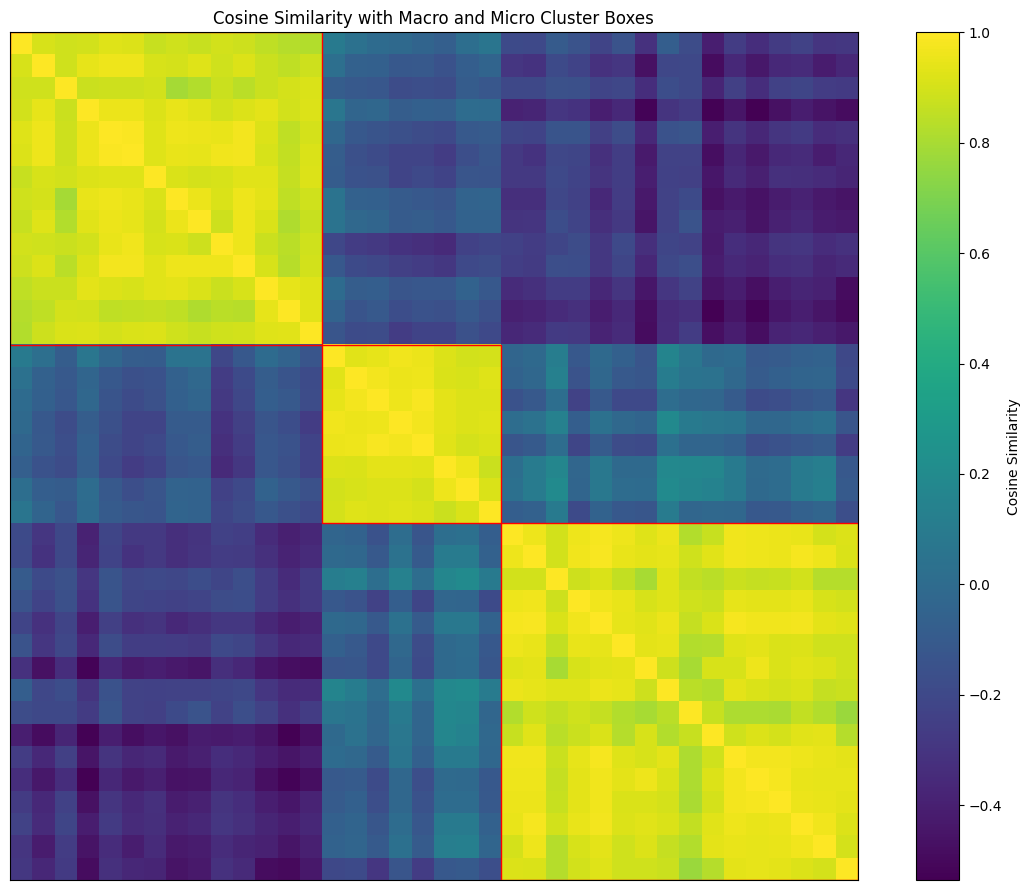

In [90]:
ftask_inds, fbatch_inds = torch.nonzero(flags, as_tuple=True)
sorted_indices = torch.argsort(ftask_inds)
batch_inds, task_inds = fbatch_inds[sorted_indices], ftask_inds[sorted_indices]
vecs = thetas[task_inds, batch_inds]
X = vecs.numpy()

# compute macro block boundaries by task_inds
boundaries = []
current_label = task_inds[0]
start_idx = 0
for idx in range(1, len(task_inds)):
    if task_inds[idx] != current_label:
        boundaries.append((start_idx, idx))
        start_idx = idx
        current_label = task_inds[idx]
boundaries.append((start_idx, len(task_inds)))

# reorder X within each block
X_reordered = []
new_order = []

# store micro-boundaries for each block to draw micro boxes
micro_boundaries_all = []

# Only keep the largest micro-cluster
for (start, end) in boundaries:
    X_block = X[start:end]

    # Perform clustering within the block
    n_clusters = min(3, end - start)
    clustering = AgglomerativeClustering(n_clusters=n_clusters, 
                                         metric='cosine', 
                                         linkage='average')
    cluster_labels = clustering.fit_predict(X_block)

    # Identify the largest microcluster
    unique, counts = np.unique(cluster_labels, return_counts=True)
    largest_cluster_label = unique[np.argmax(counts)]

    # Filter X_block to keep only the largest microcluster
    keep_mask = (cluster_labels == largest_cluster_label)
    X_block_kept = X_block[keep_mask]
    kept_indices_in_block = np.where(keep_mask)[0]

    # Sort within the largest cluster if desired (optional)
    # Here, sorting by the norm as an example
    sort_idx_in_kept = np.argsort(np.linalg.norm(X_block_kept, axis=1))

    # Compute global indices for kept points
    kept_sorted_global_indices = (start + kept_indices_in_block[sort_idx_in_kept])
    new_order.append(kept_sorted_global_indices)

    # Optionally, store micro boundaries if you wish to visualize them
    # since you are only keeping one cluster, this will be one block:
    micro_boundaries_all.append((len(np.concatenate(new_order)) - len(kept_sorted_global_indices),
                                 len(np.concatenate(new_order))))

'''
for (start, end) in boundaries:
    X_block = X[start:end]

    # perform clustering within block
    n_clusters = min(5, end - start)  # adjust based on your needs
    clustering = AgglomerativeClustering(n_clusters=n_clusters, metric='cosine', linkage='average')
    cluster_labels = clustering.fit_predict(X_block)

    # sort within block according to cluster_labels
    sort_idx = np.argsort(cluster_labels)
    new_order.append(start + sort_idx)

    # compute micro-boundaries
    cluster_labels_sorted = cluster_labels[sort_idx]
    micro_boundaries = []
    current_cluster = cluster_labels_sorted[0]
    micro_start = 0
    for idx in range(1, len(cluster_labels_sorted)):
        if cluster_labels_sorted[idx] != current_cluster:
            micro_boundaries.append((micro_start + start, idx + start))
            micro_start = idx
            current_cluster = cluster_labels_sorted[idx]
    micro_boundaries.append((micro_start + start, len(cluster_labels_sorted) + start))
    micro_boundaries_all.extend(micro_boundaries)
'''

# concatenate the new indices across blocks
new_order = np.concatenate(new_order)

# reorder X globally
X_sorted = X[new_order]
cos_sim_sorted = cosine_similarity(X_sorted)
# np.fill_diagonal(cos_sim_sorted, 0)

# plot
fig, ax = plt.subplots(figsize=(12, 9))
cax = ax.imshow(cos_sim_sorted, cmap='viridis')
plt.colorbar(cax, label='Cosine Similarity')
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Cosine Similarity with Macro and Micro Cluster Boxes")

# recompute macro boundaries under new_order
boundaries_sorted = []
current_label = task_inds[new_order[0]]
start_idx = 0
for idx in range(1, len(new_order)):
    if task_inds[new_order[idx]] != current_label:
        boundaries_sorted.append((start_idx, idx))
        start_idx = idx
        current_label = task_inds[new_order[idx]]
boundaries_sorted.append((start_idx, len(new_order)))

# draw macro boxes in red
for (start, end) in boundaries_sorted:
    width = end - start
    rect = patches.Rectangle(
        (start - 0.5, start - 0.5),
        width,
        width,
        linewidth=1,
        edgecolor='red',
        facecolor='none'
    )
    ax.add_patch(rect)

'''
# recompute micro boundaries under new_order
task_inds_new_order = task_inds[new_order]
clustering_indices = np.arange(len(new_order))

micro_boundaries_sorted = []
current_macro_idx = 0
for (start, end) in boundaries_sorted:
    # filter micro boundaries that are within this macro block
    micro_in_block = [b for b in micro_boundaries_all if start <= b[0] < end]
    micro_boundaries_sorted.extend(micro_in_block)

# draw micro boxes in white
for (start, end) in micro_boundaries_sorted:
    width = end - start
    rect = patches.Rectangle(
        (start - 0.5, start - 0.5),
        width,
        width,
        linewidth=0.5,
        edgecolor='white',
        facecolor='none'
    )
    ax.add_patch(rect)
'''

plt.tight_layout()
plt.show()


In [57]:
for k in range(config.task.n_tasks):
    task_idx = k
    demo_data, demo_target = train_task.sample_from_task(train_task.task_pool[task_idx], step=1)
    task_vector_diff = extract_task_vector_diff(model, demo_data, demo_target, l=l0, task_pos=-1, init_pos=1)

    query_data, query_target = train_task.sample_from_task(train_task.task_pool[task_idx], step=6)
    
    preds = predict_with_task_vector_diff(model, query_data, query_target, task_vector_diff, l=l0, lamda=0.05)
    loss = nn.MSELoss()(preds[:,0], query_target[:,0].to(preds.device))
    print(f"Zero-shot prediction loss with injected task vector: {loss.item():.4f}")

Zero-shot prediction loss with injected task vector: 6.3680
Zero-shot prediction loss with injected task vector: 3.5206
Zero-shot prediction loss with injected task vector: 3.9208


In [58]:
for k in range(config.task.n_tasks):
    task_idx = k
    demo_data, demo_target = train_task.sample_from_task(train_task.task_pool[task_idx], step=1)
    rand_vec = torch.randn(config.model.n_embd).to(config.device)

    query_data, query_target = train_task.sample_from_task(train_task.task_pool[task_idx], step=6)
    
    preds_rand = predict_with_task_vector(
        model=model,
        query_data=query_data[:,:1],
        query_target=query_target[:,:1],
        task_vector=rand_vec,
        l=l0,              # same layer
        pad="mapsto"      # same position
    )
    
    loss = nn.MSELoss()(preds_rand[:,0], query_target[:,0].to(preds.device))
    print(f"Zero-shot prediction loss with injected task vector: {loss.item():.6f}")

Zero-shot prediction loss with injected task vector: 14.846551
Zero-shot prediction loss with injected task vector: 4.429854
Zero-shot prediction loss with injected task vector: 3.236413


In [59]:
for k in range(config.task.n_tasks):
    task_idx = k
    tmask = task_inds == k
    query_data, query_target = train_task.sample_from_task(train_task.task_pool[task_idx], step=1)
    Xtask = torch.tensor(X_sorted[task_inds[new_order]==k], device=task_vectors.device)
    preds = predict_with_task_vector(
        model=model,
        query_data=query_data[:,:1],
        query_target=query_target[:,:1],
        task_vector=Xtask[0],
        l=l0,              # same layer
        pad="mapsto"        # same position
    )
    
    loss = nn.MSELoss()(preds[:,0], query_target[:,0].to(preds.device))
    print(f"Zero-shot prediction loss with injected task vector: {loss.item():.6f}")

Zero-shot prediction loss with injected task vector: 0.260510
Zero-shot prediction loss with injected task vector: 0.232967
Zero-shot prediction loss with injected task vector: 0.227762


In [60]:
# Compute projection
closest_rows = torch.zeros((config.task.n_tasks, task_vectors.shape[-1]))
for k in range(config.task.n_tasks):
    task_idx = k
    Xtask = X_sorted[task_inds[new_order]==k]
    diff = torch.tensor(Xtask, device=task_vectors.device) - task_vectors[task_idx].unsqueeze(0)  # (n, d)
    dists = diff.norm(dim=1)  # (n,)
    closest_idx = torch.argmin(dists)
    closest_rows[k] = torch.tensor(Xtask[closest_idx])

In [61]:
(closest_rows - task_vectors.cpu()).norm(dim=-1)

tensor([13.616, 13.215, 12.470])

In [30]:
for k in range(config.task.n_tasks):
    task_idx = k
    # Compute projection
    Xtask = X_sorted[task_inds[new_order]==k]
    vec_norms = np.linalg.norm(Xtask, axis=-1)
    med_norm = np.median(vec_norms)
    AtA_inv = np.linalg.inv(Xtask @ Xtask.T)
    P = torch.tensor(Xtask.T @ AtA_inv @ Xtask)
    v_parallel = P @ task_vectors[task_idx].cpu()
    query_data, query_target = train_task.sample_from_task(train_task.task_pool[task_idx], step=6)
    
    preds = predict_with_task_vector(
        model=model,
        query_data=query_data,
        query_target=query_target,
        task_vector=v_parallel.to(task_vectors[task_idx].device),
        l=l0,              # same layer
        pad="mapsto",       # same position
        optimize=True,
        num_epochs=10,
        lr=1e-3,
        train_task=train_task,
        task_idx=task_idx
    )
    
    loss = nn.MSELoss()(preds[:,0], query_target[:,0].to(preds.device))
    print(f"Zero-shot prediction loss with injected task vector: {loss.item():.6f}")

Zero-shot prediction loss with injected task vector: 1.364372
Zero-shot prediction loss with injected task vector: 2.559825
Zero-shot prediction loss with injected task vector: 0.667475
Zero-shot prediction loss with injected task vector: 2.239479
Zero-shot prediction loss with injected task vector: 4.787960


In [62]:
cosine_similarity(task_vectors.cpu())

array([[1.   , 0.475, 0.419],
       [0.475, 1.   , 0.554],
       [0.419, 0.554, 1.   ]], dtype=float32)

array([[ 1.   , -0.164, -0.085],
       [-0.164,  1.   ,  0.38 ],
       [-0.085,  0.38 ,  1.   ]], dtype=float32)

In [64]:
cosine_similarity(closest_rows.cpu())

array([[ 1.   , -0.116, -0.431],
       [-0.116,  1.   , -0.111],
       [-0.431, -0.111,  1.   ]], dtype=float32)